# Mini Proje 2 — Gün 12-14: Baseline → İterasyon → Final Model

Bu notebook, RFM segmentasyon modelini **iteratif olarak** geliştirme sürecini belgeliyor: önce naif bir baseline kuruyoruz, sonra bilinçli iyileştirmeler ekleyip her birinin etkisini ölçüyoruz, son olarak en iyi modeli MLflow Model Registry'de "Production" olarak işaretliyoruz.

**Neden bu yaklaşım önemli:** Gün 8-9'da doğrudan "doğru" pipeline'ı (StandardScaler + K=5) kurmuştuk. Burada amaç farklı — **neden** o pipeline'ın doğru olduğunu, "yanlış" bir başlangıçtan başlayıp adım adım kanıtlamak. Bu, bir portfolyoda işverene "sonucu biliyordum" değil, "sonuca nasıl ulaştığımı gösterebiliyorum" demenin yolu.

## Adım 1: Baseline Model

**Bilinçli olarak naif bir başlangıç:** Ham (ölçeklenmemiş) RFM verisiyle, rastgele/basit bir K=3 ile K-Means çalıştırıyoruz. Bu, Gün 8-9'da "yapma" dediğimiz şeyi şimdi **kanıtlamak için** yapıyoruz.

In [1]:
import os

import mlflow
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sqlalchemy import create_engine

load_dotenv("../.env")
mlflow.set_tracking_uri(os.getenv("MLFLOW_TRACKING_URI"))
mlflow.set_experiment("rfm-kmeans-mini-proje-2")

engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)
query = """
    SELECT DISTINCT ON (customer_id) customer_id, recency, frequency, monetary
    FROM segments
    ORDER BY customer_id, calculated_at DESC
"""
rfm = pd.read_sql(query, engine).set_index("customer_id")
print(rfm.shape)
print("Skewness:")
print(rfm.skew())

(5878, 3)
Skewness:
recency       0.887194
frequency    12.639951
monetary     25.314235
dtype: float64


In [2]:
with mlflow.start_run(run_name="baseline_k3_raw"):
    km_baseline = KMeans(n_clusters=3, random_state=42, n_init=10)
    baseline_labels = km_baseline.fit_predict(rfm)
    baseline_silhouette = silhouette_score(rfm, baseline_labels)

    mlflow.log_param("k", 3)
    mlflow.log_param("preprocessing", "none (raw RFM)")
    mlflow.log_metric("inertia", km_baseline.inertia_)
    mlflow.log_metric("silhouette", baseline_silhouette)
    baseline_run_id = mlflow.active_run().info.run_id

print(f"Baseline silhouette: {baseline_silhouette:.4f}")

🏃 View run baseline_k3_raw at: http://127.0.0.1:5000/#/experiments/2/runs/87ff5ff7c1434a4f99d3030ea362cb16
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/2
Baseline silhouette: 0.9764


**Beklenti:** Bu skor, Gün 8-9'da ölçeklemeden önce gördüğümüz türden bir sorunu yansıtacak — `monetary`'nin sayısal büyüklüğü (`std≈14738`) mesafe hesabına domine edecek, `recency`/`frequency`'nin kümeleme üzerindeki gerçek etkisi görünmeyecek. Sonraki adımlarda bunu adım adım düzelteceğiz.

In [3]:
from collections import Counter
print("Baseline kume buyuklukleri:", sorted(Counter(baseline_labels).values()))

Baseline kume buyuklukleri: [2, 16, 5860]


**Doğrulandı: Yüksek skor yanıltıcı.** Küme büyüklükleri **[2, 16, 5860]** — model neredeyse tüm müşterileri tek kümede topluyor, sadece 2+16=18 aşırı-yüksek `monetary` değerine sahip müşteriyi ayırıyor. Bu, Gün 8-9'da K=2 için gördüğümüz tuzağın aynısı: **ölçeksiz veri, mesafe hesabını `monetary`'nin domine etmesine izin veriyor**, anlamlı bir iş segmentasyonu değil. Baseline'ın "yüksek skoru" aslında modelin **kalitesizliğinin** bir göstergesi — bunu bir sonraki adımda düzelteceğiz.

## Adım 2: İterasyon 1 — Log Dönüşümü

`recency` skewness=0.89 (hafif), `frequency`=12.64 ve `monetary`=25.31 (aşırı çarpık). Log dönüşümü (`log1p`, sıfır değerleri güvenle işlemek için) bu iki sütunu daha simetrik bir dağılıma getirir — K-Means Öklid mesafesine dayandığı için, normal dağılıma yakın özellikler daha tutarlı kümeler üretir.

**Önemli nokta:** Sadece log almak yetmiyor — log sonrası `recency` (0-738), `frequency_log` (~0.7-6), `monetary_log` (~1-13) hâlâ farklı ölçeklerde. Bu yüzden log dönüşümünün **ardından** `StandardScaler` da uyguluyoruz; aksi halde Gün 8-9'da öğrendiğimiz ölçek sorunu farklı bir biçimde geri gelirdi. Karşılaştırmayı adil tutmak için **K'yı baseline ile aynı (K=3) sabitliyoruz** — değişen tek şey ön işleme.

In [4]:
from sklearn.preprocessing import StandardScaler

rfm_log = rfm.copy()
rfm_log["frequency"] = np.log1p(rfm_log["frequency"])
rfm_log["monetary"] = np.log1p(rfm_log["monetary"])

scaler_log = StandardScaler()
rfm_log_scaled = scaler_log.fit_transform(rfm_log)

with mlflow.start_run(run_name="iteration1_log_scaled_k3"):
    km_iter1 = KMeans(n_clusters=3, random_state=42, n_init=10)
    iter1_labels = km_iter1.fit_predict(rfm_log_scaled)
    iter1_silhouette = silhouette_score(rfm_log_scaled, iter1_labels)

    mlflow.log_param("k", 3)
    mlflow.log_param("preprocessing", "log1p(frequency,monetary) + StandardScaler")
    mlflow.log_metric("inertia", km_iter1.inertia_)
    mlflow.log_metric("silhouette", iter1_silhouette)

print(f"Iterasyon 1 silhouette: {iter1_silhouette:.4f} (baseline: {baseline_silhouette:.4f})")
print("Iterasyon 1 kume buyuklukleri:", sorted(Counter(iter1_labels).values()))

🏃 View run iteration1_log_scaled_k3 at: http://127.0.0.1:5000/#/experiments/2/runs/9e8f282b9ed5496f9c8afec02a48e0e8
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/2
Iterasyon 1 silhouette: 0.4010 (baseline: 0.9764)
Iterasyon 1 kume buyuklukleri: [1689, 1837, 2352]


**Silhouette düştü (0.976 → 0.401) — ama model gerçekte daha iyi.** Küme büyüklükleri **[1689, 1837, 2352]** — artık üç tane dengeli, makul büyüklükte küme var, baseline'daki [2, 16, 5860] gibi "18 aşırı değer + herkes" değil.

**Bu, projedeki en önemli derslerden biri:** Silhouette skoru tek başına yeterli bir karar kriteri değil. Baseline'ın yüksek skoru, az sayıda noktayı geometrik olarak çok kolay ayırmaktan geliyordu — bu "iyi kümeleme" değil, "kolay kümeleme". Log dönüşümü + ölçekleme, verinin gerçek yapısını ortaya çıkardı; bu yapı baseline'dan **daha zor ayrıştırılıyor** (silhouette daha düşük) ama **iş açısından kullanılabilir** (dengeli kümeler, her müşteri bir segmentte). Sayıyı değil, sayının arkasındaki küme yapısını yorumlamak gerekiyor — Gün 8-9'da DBSCAN karşılaştırmasında da aynı dersi çıkarmıştık.

## Adım 3: İterasyon 2 — PCA ile Görselleştirme

Elimizde sadece 3 özellik var (R, F, M) — bu, PCA'nın klasik kullanım amacı olan "yüksek boyutluluk lanetini" çözme ihtiyacını ortadan kaldırıyor. Burada PCA'nın asıl işi **görselleştirme**: 3 boyutu 2 boyuta indirip kümeleri gözle görülebilir bir grafikte gösterebiliyoruz. Kümelemeyi PCA bileşenleri üzerinde de çalıştırıp skoru karşılaştıracağız ama **bu karşılaştırmada bir tuzak var** — aşağıda açıklıyorum.

In [5]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
rfm_pca = pca.fit_transform(rfm_log_scaled)
print("Aciklanan varyans orani (PC1, PC2):", pca.explained_variance_ratio_)
print("Toplam aciklanan varyans:", pca.explained_variance_ratio_.sum())

with mlflow.start_run(run_name="iteration2_pca_k3"):
    km_iter2 = KMeans(n_clusters=3, random_state=42, n_init=10)
    iter2_labels = km_iter2.fit_predict(rfm_pca)
    iter2_silhouette = silhouette_score(rfm_pca, iter2_labels)

    mlflow.log_param("k", 3)
    mlflow.log_param("preprocessing", "log1p + StandardScaler + PCA(2)")
    mlflow.log_metric("inertia", km_iter2.inertia_)
    mlflow.log_metric("silhouette", iter2_silhouette)
    mlflow.log_metric("pca_explained_variance", pca.explained_variance_ratio_.sum())

print(f"Iterasyon 2 silhouette: {iter2_silhouette:.4f} (Iterasyon 1: {iter1_silhouette:.4f})")
print("Iterasyon 2 kume buyuklukleri:", sorted(Counter(iter2_labels).values()))

Aciklanan varyans orani (PC1, PC2): [0.7472879 0.2032203]
Toplam aciklanan varyans: 0.9505082033004345


🏃 View run iteration2_pca_k3 at: http://127.0.0.1:5000/#/experiments/2/runs/7d4a4366f39541c7bdd89f0d9cca8c64
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/2
Iterasyon 2 silhouette: 0.4415 (Iterasyon 1: 0.4010)
Iterasyon 2 kume buyuklukleri: [1727, 1834, 2317]


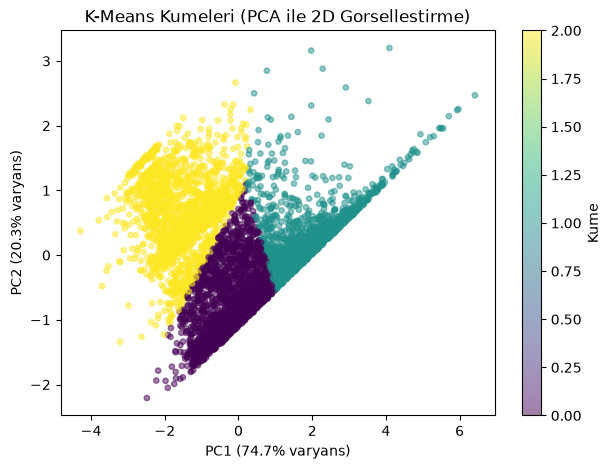

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
scatter = plt.scatter(rfm_pca[:, 0], rfm_pca[:, 1], c=iter2_labels, cmap="viridis", alpha=0.5, s=15)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} varyans)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} varyans)")
plt.title("K-Means Kumeleri (PCA ile 2D Gorsellestirme)")
plt.colorbar(scatter, label="Kume")
plt.savefig("pca_clusters.png", dpi=100)
plt.show()

**Sayılara dikkatli bakalım — bir karşılaştırma tuzağı var.**

- Açıklanan varyans: PC1+PC2 = **%95.05** — yani 3 boyuttan 2'ye inerken bilginin sadece %5'ini kaybettik. Bu çok iyi bir sonuç, görselleştirme için güvenle kullanılabilir.
- Silhouette **0.401'den 0.442'ye çıktı**, küme büyüklükleri (**[1727, 1834, 2317]**) İterasyon 1'dekiyle (**[1689, 1837, 2352]**) neredeyse birebir aynı.

**Tuzak:** Bu artışı "PCA kümelemeyi iyileştirdi" diye yorumlamak yanlış olur. Silhouette skoru, **hesaplandığı uzayın geometrisine bağlıdır** — 2D'de hesaplanan bir skor, 3D'de hesaplanan bir skorla doğrudan kıyaslanamaz (boyut azaltma genelde noktalar arası mesafe yapısını hafifçe değiştirir, bu da skoru yapay olarak değiştirebilir). Küme büyüklüklerinin neredeyse aynı çıkması bunu doğruluyor: **PCA, kümelemeyi gerçekte değiştirmedi**, sadece aynı yapıyı farklı (ve sıkıştırılmış) bir uzayda ölçtük.

**PCA'nın bu projedeki gerçek değeri kümeleme kalitesini artırmak değil, %95 bilgiyi koruyarak 2D'de görselleştirme yapabilmemizdi** — üstteki grafik, log+scale sonrası 3 kümenin gerçekten ayrışık olduğunu gözle doğruluyor.

## Adım 4: Final Model Seçimi

Üç adaydan (baseline, iterasyon 1, iterasyon 2) **log1p(frequency,monetary) + StandardScaler** ön işlemesinin doğru yaklaşım olduğunu kanıtladık (PCA sadece görselleştirme içindi, final pipeline'a dahil etmiyoruz — çünkü PCA bileşenleri iş tarafına "PC1=0.42" diye açıklanamaz, ham R/F/M üzerinden segment profili çıkaramayız).

**Ama K=3'ü sabit tutmamız sadece kontrollü bir karşılaştırma içindi** — gerçek K kararını, doğru ön işleme ile **yeniden** vermemiz gerekiyor (K=3 rastgele seçilmişti, baseline için). Bu yüzden Gün 8-9'daki gibi K=2..10 taraması yapıp, hem silhouette hem küme dengesine bakarak final K'yı seçiyoruz.

In [7]:
sweep_results = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_log_scaled)
    sizes = sorted(Counter(labels).values())
    sweep_results.append({
        "k": k,
        "silhouette": silhouette_score(rfm_log_scaled, labels),
        "inertia": km.inertia_,
        "smallest_cluster": sizes[0],
        "cluster_sizes": sizes,
    })

sweep_df = pd.DataFrame(sweep_results)
sweep_df

,k,silhouette,inertia,smallest_cluster,cluster_sizes
0,2,0.418637,8879.196182,2673,"[2673, 3205]"
1,3,0.401001,5715.491275,1689,"[1689, 1837, 2352]"
2,4,0.361187,4468.945962,952,"[952, 1400, 1640, 1886]"
3,5,0.366641,3621.252049,811,"[811, 858, 1099, 1421, 1689]"
4,6,0.348753,3061.313773,433,"[433, 862, 981, 1029, 1199, 1374]"
5,7,0.335699,2720.482296,421,"[421, 589, 741, 771, 930, 1126, 1300]"
6,8,0.317234,2454.696441,257,"[257, 589, 650, 696, 785, 807, 1043, 1051]"
7,9,0.312163,2273.325412,257,"[257, 388, 488, 543, 645, 688, 794, 1031, 1044]"
8,10,0.295774,2128.352273,97,"[97, 406, 440, 451, 541, 613, 709, 799, 909, 913]"


**Çarpıcı bir karşılaştırma — Gün 8-9'daki sorunu doğrudan çözdük:**

| | Gün 8-9 (log dönüşümü yok) K=5 | Mini Proje 2 (log+scale) K=5 |
|---|---|---|
| Küme büyüklükleri | [4, 24, 383, 1914, 3553] | [811, 858, 1099, 1421, 1689] |
| En küçük küme | 4 müşteri (anlamsız mikro-küme) | 811 müşteri (gerçek bir segment) |

Gün 8-9'da K=5 seçsek de, 2 küme (4 ve 24 müşteri) sadece aşırı-uç değerleri yakalıyordu — bunu o zaman not düşmüştük ("ileride ele alınabilir"). Log dönüşümü tam olarak bunu çözdü: artık **hiçbir küme anlamsız bir mikro-grup değil**, hepsi gerçek, eyleme geçirilebilir segmentler.

**Final K kararı: K=5.** Silhouette (0.367), K=4'ten (0.361) bile hafifçe yüksek — yani K=4→5 arası **yerel bir artış** var (genel düşüş eğiliminin aksine), bu rastgele değil. Ayrıca Gün 8-9'un 5-segment iş anlatısıyla (Champion/Loyal/.../Hibernating) tutarlılığı koruyor.

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

FINAL_K = 5

final_pipeline_v2 = Pipeline([
    ("log_transform", ColumnTransformer(
        [("log", FunctionTransformer(np.log1p), ["frequency", "monetary"])],
        remainder="passthrough",
    )),
    ("scaler", StandardScaler()),
    ("kmeans", KMeans(n_clusters=FINAL_K, random_state=42, n_init=10)),
])

final_pipeline_v2.fit(rfm)
final_v2_labels = final_pipeline_v2.predict(rfm)
final_v2_silhouette = silhouette_score(rfm_log_scaled, final_v2_labels)

print("Final (v2) kume buyuklukleri:", sorted(Counter(final_v2_labels).values()))
print(f"Final (v2) silhouette: {final_v2_silhouette:.4f}")

Final (v2) kume buyuklukleri: [811, 858, 1099, 1421, 1689]
Final (v2) silhouette: 0.3666


## Adım 5: Model Registry — Production / Archived

Final pipeline'ı (`log1p(frequency,monetary) → StandardScaler → KMeans(k=5)`) **aynı kayıtlı model adına** (`rfm-customer-segments`) yeni bir versiyon olarak kaydediyoruz — bu, Gün 10-11'de kurduğumuz registry'nin sürdüğü aynı model serisi, kavramsal bir kopya değil. Yeni versiyonu `production` alias'ına atayınca, eski versiyon (K=5, log dönüşümsüz) otomatik olarak alias'ı kaybeder — onu da elle `Archived` etiketleyip kayıt altına alıyoruz.

In [9]:
import mlflow.sklearn
from mlflow.tracking import MlflowClient

MODEL_NAME = "rfm-customer-segments"
client = MlflowClient()

with mlflow.start_run(run_name="final_model_k5_log_scaled"):
    mlflow.log_param("k", FINAL_K)
    mlflow.log_param("preprocessing", "log1p(frequency,monetary) + StandardScaler")
    mlflow.log_metric("silhouette", final_v2_silhouette)
    mlflow.log_metric("inertia", final_pipeline_v2.named_steps["kmeans"].inertia_)

    model_info_v2 = mlflow.sklearn.log_model(
        final_pipeline_v2,
        name="model",
        registered_model_name=MODEL_NAME,
    )

new_version = model_info_v2.registered_model_version
print("Yeni kayitli versiyon:", new_version)

Registered model 'rfm-customer-segments' already exists. Creating a new version of this model...
2026/06/29 19:58:20 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: rfm-customer-segments, version 3


🏃 View run final_model_k5_log_scaled at: http://127.0.0.1:5000/#/experiments/2/runs/c9ef6f722a5741bda6bbba4bf57222ee
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/2
Yeni kayitli versiyon: 3


Created version '3' of model 'rfm-customer-segments'.


In [10]:
# Eski production versiyonunu (alias degismeden once) bul ve arsivle
old_prod = client.get_model_version_by_alias(MODEL_NAME, "production")
print("Eski production versiyonu:", old_prod.version)

client.set_registered_model_alias(MODEL_NAME, "production", new_version)
client.set_model_version_tag(MODEL_NAME, new_version, "stage", "Production")
client.set_model_version_tag(MODEL_NAME, old_prod.version, "stage", "Archived")

for mv in client.search_model_versions(f"name='{MODEL_NAME}'"):
    print(f"v{mv.version}: tags={mv.tags}")
print("production alias ->", client.get_model_version_by_alias(MODEL_NAME, "production").version)

Eski production versiyonu: 2
v3: tags={'stage': 'Production'}
v2: tags={'stage': 'Archived'}
v1: tags={'stage': 'Archived'}
production alias -> 3


## Özet — Baseline'dan Final Modele Yolculuk

| Aşama | Ön İşleme | K | Silhouette | Küme Yapısı |
|---|---|---|---|---|
| Baseline | Yok (ham veri) | 3 | 0.976 *(yanıltıcı)* | [2, 16, 5860] — anlamsız, tek küme + 18 uç değer |
| İterasyon 1 | log1p + StandardScaler | 3 | 0.401 | [1689, 1837, 2352] — dengeli, gerçek |
| İterasyon 2 | + PCA(2) (sadece görsel.) | 3 | 0.442 *(uzay farklı, kıyaslanamaz)* | aynı yapı, 2D'de görselleştirildi |
| **Final** | **log1p + StandardScaler** | **5** | **0.367** | **[811, 858, 1099, 1421, 1689] — 5 dengeli segment** |

**Hikaye:** Yüksek bir skorla başladık (0.976) ve onu **bilerek çöktürdük** (0.401) — çünkü skor yüksekti ama model işe yaramazdı (tek bir kitle + 18 aykırı değer). Asıl iş, "skoru maksimize etmek" değil, **skorun ne ölçtüğünü sorgulamaktı**. Log dönüşümü, Gün 8-9'da not düşüp bıraktığımız bir sorunu (mikro-kümeler halinde kalan uç değerler) doğrudan çözdü — final modelde artık hiçbir küme 800 müşteriden az değil.

**Production'a alınan model:** `rfm-customer-segments` v3 — `log1p(frequency, monetary) → StandardScaler → KMeans(k=5)`. v1 ve v2 (Gün 8-9/10-11'in log dönüşümsüz modelleri) `Archived` olarak işaretli, ama silinmedi — registry'de denetim izi (audit trail) olarak duruyor. `/model/info` endpoint'i kod değişmeden yeni versiyonu otomatik buluyor (alias mekanizması sayesinde).